In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt
import scipy.stats as stats
import warnings
pd.options.display.max_columns=None

In [2]:
test = pd.read_csv('/kaggle/input/precio-portatiles/test.csv')
test.head() 

,id,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight
0,824,833,Lenovo,ThinkPad X1,Ultrabook,14.0,IPS Panel Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB Flash Storage,Intel HD Graphics 620,Windows 10,1.13kg
1,101,104,HP,15-bw000nv (E2-9000e/4GB/500GB/Radeon,Notebook,15.6,Full HD 1920x1080,AMD E-Series E2-9000e 1.5GHz,4GB,500GB HDD,AMD Radeon R2,Windows 10,2.1kg
2,1157,1175,Lenovo,ThinkPad T460s,Ultrabook,14.0,Full HD 1920x1080,Intel Core i7 6600U 2.6GHz,12GB,512GB SSD,Intel HD Graphics 520,Windows 7,1.4kg
3,940,954,HP,Omen 17-W006na,Gaming,17.3,IPS Panel Full HD 1920x1080,Intel Core i5 6300HQ 2.3GHz,8GB,128GB SSD + 1TB HDD,Nvidia GeForce GTX 965M,Windows 10,2.75kg
4,853,864,Lenovo,ThinkPad T470p,Ultrabook,14.0,IPS Panel Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,8GB,256GB SSD,Nvidia GeForce GT 940MX,Windows 10,1.96kg


In [3]:
train = pd.read_csv('/kaggle/input/precio-portatiles/train.csv')
train.head()

,id,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
0,697,705,Asus,Chromebook Flip,2 in 1 Convertible,12.5,Full HD / Touchscreen 1920x1080,Intel Core M M3-6Y30 0.9GHz,4GB,64GB Flash Storage,Intel HD Graphics 515,Chrome OS,1.2kg,669.0
1,435,442,Asus,Rog Strix,Gaming,17.3,Full HD 1920x1080,AMD Ryzen 1600 3.2GHz,8GB,256GB SSD + 1TB HDD,AMD Radeon RX 580,Windows 10,3.2kg,1695.0
2,735,743,Lenovo,V310-15IKB (i7-7500U/4GB/1TB/FHD/W10),Notebook,15.6,Full HD 1920x1080,Intel Core i7 7500U 2.7GHz,4GB,1TB HDD,Intel HD Graphics 620,Windows 10,1.85kg,779.0
3,864,875,Dell,XPS 13,Ultrabook,13.3,Quad HD+ / Touchscreen 3200x1800,Intel Core i7 7660U 2.5GHz,16GB,512GB SSD,Intel Iris Plus Graphics 640,Windows 10,1.29kg,2240.0
4,1176,1194,Lenovo,B51-80 (i7-6500U/4GB/1008GB/FHD/W7),Notebook,15.6,Full HD 1920x1080,Intel Core i7 6500U 2.5GHz,4GB,1.0TB Hybrid,Intel HD Graphics 520,Windows 7,2.32kg,825.0


In [4]:
combined = pd.concat([train,test])
combined.head()

,id,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
0,697,705,Asus,Chromebook Flip,2 in 1 Convertible,12.5,Full HD / Touchscreen 1920x1080,Intel Core M M3-6Y30 0.9GHz,4GB,64GB Flash Storage,Intel HD Graphics 515,Chrome OS,1.2kg,669.0
1,435,442,Asus,Rog Strix,Gaming,17.3,Full HD 1920x1080,AMD Ryzen 1600 3.2GHz,8GB,256GB SSD + 1TB HDD,AMD Radeon RX 580,Windows 10,3.2kg,1695.0
2,735,743,Lenovo,V310-15IKB (i7-7500U/4GB/1TB/FHD/W10),Notebook,15.6,Full HD 1920x1080,Intel Core i7 7500U 2.7GHz,4GB,1TB HDD,Intel HD Graphics 620,Windows 10,1.85kg,779.0
3,864,875,Dell,XPS 13,Ultrabook,13.3,Quad HD+ / Touchscreen 3200x1800,Intel Core i7 7660U 2.5GHz,16GB,512GB SSD,Intel Iris Plus Graphics 640,Windows 10,1.29kg,2240.0
4,1176,1194,Lenovo,B51-80 (i7-6500U/4GB/1008GB/FHD/W7),Notebook,15.6,Full HD 1920x1080,Intel Core i7 6500U 2.5GHz,4GB,1.0TB Hybrid,Intel HD Graphics 520,Windows 7,2.32kg,825.0


In [5]:
combined.shape

(1303, 14)

In [6]:
combined.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1303 entries, 0 to 390
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                1303 non-null   int64  
 1   laptop_ID         1303 non-null   int64  
 2   Company           1303 non-null   object 
 3   Product           1303 non-null   object 
 4   TypeName          1303 non-null   object 
 5   Inches            1303 non-null   float64
 6   ScreenResolution  1303 non-null   object 
 7   Cpu               1303 non-null   object 
 8   Ram               1303 non-null   object 
 9   Memory            1303 non-null   object 
 10  Gpu               1303 non-null   object 
 11  OpSys             1303 non-null   object 
 12  Weight            1303 non-null   object 
 13  Price_euros       912 non-null    float64
dtypes: float64(2), int64(2), object(10)
memory usage: 152.7+ KB


In [7]:
combined.dtypes

id                    int64
laptop_ID             int64
Company              object
Product              object
TypeName             object
Inches              float64
ScreenResolution     object
Cpu                  object
Ram                  object
Memory               object
Gpu                  object
OpSys                object
Weight               object
Price_euros         float64
dtype: object

In [8]:
combined.describe().T

,count,mean,std,min,25%,50%,75%,max
id,1303.0,651.000000,376.288010,0.0,325.5,651.0,976.5,1302.0
laptop_ID,1303.0,660.155794,381.172104,1.0,331.5,659.0,990.5,1320.0
Inches,1303.0,15.017191,1.426304,10.1,14.0,15.6,15.6,18.4
Price_euros,912.0,1126.920340,696.088870,174.0,589.0,952.0,1499.0,4899.0


In [9]:
combined.isnull().sum()/len('combined')*100

id                     0.0
laptop_ID              0.0
Company                0.0
Product                0.0
TypeName               0.0
Inches                 0.0
ScreenResolution       0.0
Cpu                    0.0
Ram                    0.0
Memory                 0.0
Gpu                    0.0
OpSys                  0.0
Weight                 0.0
Price_euros         4887.5
dtype: float64

In [12]:
combined.skew

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


<bound method DataFrame.skew of        id  laptop_ID Company                                Product  \
0     697        705    Asus                        Chromebook Flip   
1     435        442    Asus                              Rog Strix   
2     735        743  Lenovo  V310-15IKB (i7-7500U/4GB/1TB/FHD/W10)   
3     864        875    Dell                                 XPS 13   
4    1176       1194  Lenovo    B51-80 (i7-6500U/4GB/1008GB/FHD/W7)   
..    ...        ...     ...                                    ...   
386   292        297      HP      17-BS037cl (i3-6006U/8GB/1TB/W10)   
387   688        696      HP    17-Y002nv (A10-9600P/6GB/2TB/Radeon   
388   910        923    Dell                          Latitude 5480   
389    54         55    Acer                               Aspire 3   
390  1167       1185  Lenovo    320-15ISK (i3-6006U/4GB/1TB/GeForce   

               TypeName  Inches                  ScreenResolution  \
0    2 in 1 Convertible    12.5   Full HD / To

In [13]:
combined.kurt

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


<bound method DataFrame.kurt of        id  laptop_ID Company                                Product  \
0     697        705    Asus                        Chromebook Flip   
1     435        442    Asus                              Rog Strix   
2     735        743  Lenovo  V310-15IKB (i7-7500U/4GB/1TB/FHD/W10)   
3     864        875    Dell                                 XPS 13   
4    1176       1194  Lenovo    B51-80 (i7-6500U/4GB/1008GB/FHD/W7)   
..    ...        ...     ...                                    ...   
386   292        297      HP      17-BS037cl (i3-6006U/8GB/1TB/W10)   
387   688        696      HP    17-Y002nv (A10-9600P/6GB/2TB/Radeon   
388   910        923    Dell                          Latitude 5480   
389    54         55    Acer                               Aspire 3   
390  1167       1185  Lenovo    320-15ISK (i3-6006U/4GB/1TB/GeForce   

               TypeName  Inches                  ScreenResolution  \
0    2 in 1 Convertible    12.5   Full HD / To

<Axes: >

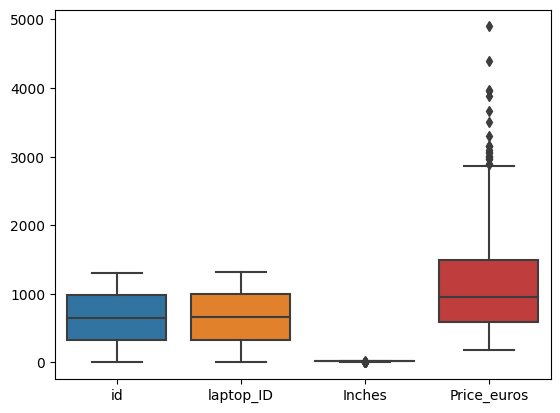

In [14]:
sns.boxplot(combined)

<Axes: >

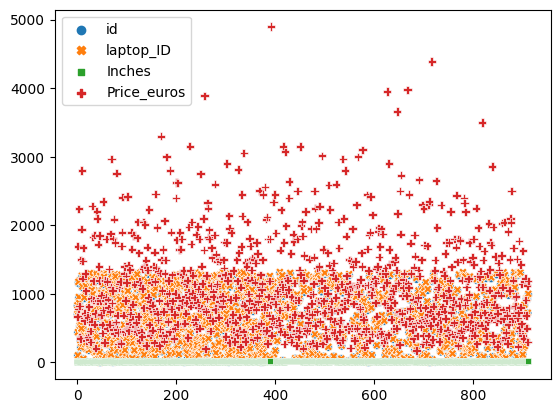

In [15]:
sns.scatterplot(combined)

<Axes: >

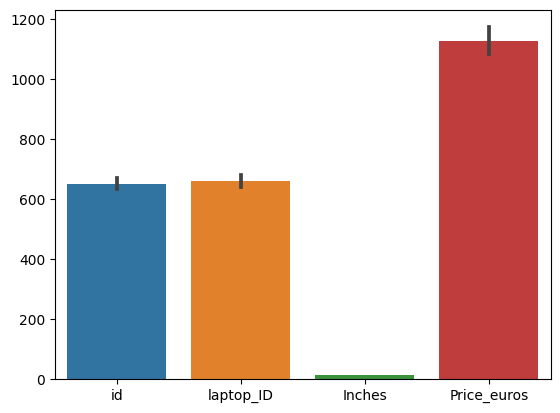

In [16]:
sns.barplot(combined)

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  

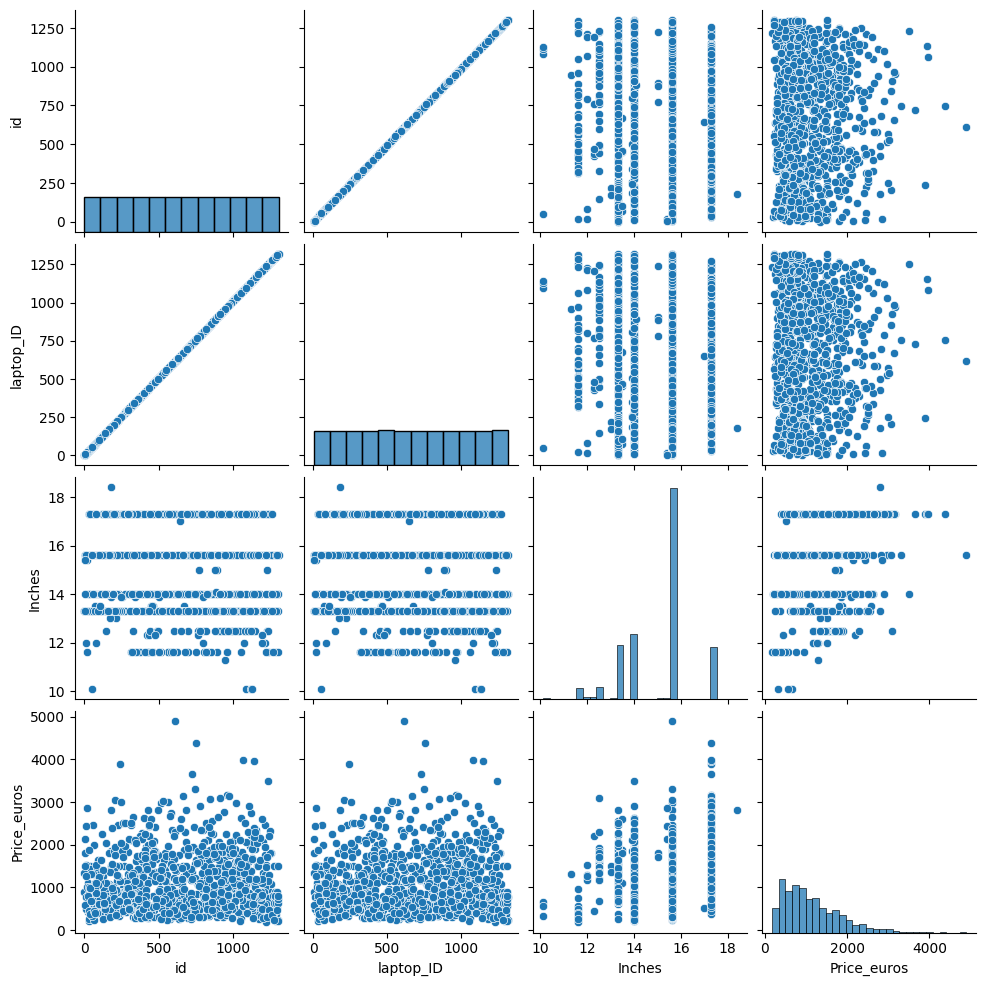

In [17]:
sns.pairplot(combined)

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

<Axes: ylabel='Density'>

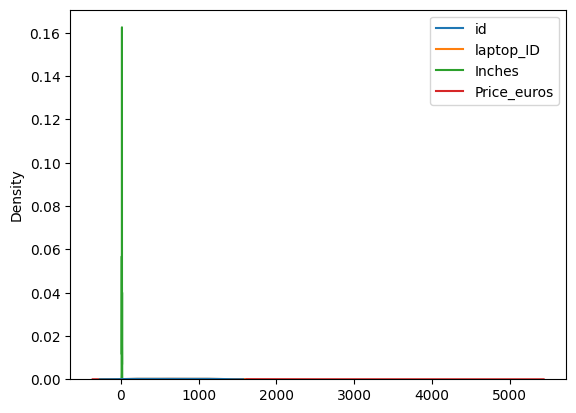

In [18]:
sns.kdeplot(combined)

In [24]:
cat_cols = combined.select_dtypes(include='object')

In [25]:
for i in cat_cols:
    print(combined[i].value_counts())
    print(i)
    print(''*50)

Company
Dell         297
Lenovo       297
HP           274
Asus         158
Acer         103
MSI           54
Toshiba       48
Apple         21
Samsung        9
Mediacom       7
Razer          7
Microsoft      6
Vero           4
Xiaomi         4
Google         3
Fujitsu        3
Chuwi          3
LG             3
Huawei         2
Name: count, dtype: int64
Company

Product
XPS 13                                          30
Inspiron 3567                                   29
250 G6                                          21
Vostro 3568                                     19
Legion Y520-15IKBN                              19
                                                ..
Q534UX-BHI7T19 (i7-7500U/16GB/2TB                1
ES1-523-84K7 (A8-7410/8GB/256GB/FHD/W10)         1
Rog GL552VW-DM201T                               1
X541UA-DM1897 (i3-6006U/4GB/256GB/FHD/Linux)     1
320-15ISK (i3-6006U/4GB/1TB/GeForce              1
Name: count, Length: 618, dtype: int64
Product

TypeName
Notebook

In [27]:
num_cols = combined.select_dtypes(include='number')

In [28]:
for i in num_cols:
    print(combined[i].value_counts())
    print(i)
    print(''*50)

id
697     1
37      1
417     1
1043    1
1184    1
       ..
793     1
1151    1
1012    1
1288    1
1167    1
Name: count, Length: 1303, dtype: int64
id

laptop_ID
705     1
38      1
424     1
1057    1
1202    1
       ..
802     1
1169    1
1026    1
1306    1
1185    1
Name: count, Length: 1303, dtype: int64
laptop_ID

Inches
15.6    665
14.0    197
13.3    164
17.3    164
12.5     39
11.6     33
13.9      6
12.0      6
13.5      6
12.3      5
15.0      4
15.4      4
10.1      4
13.0      2
17.0      1
18.4      1
11.3      1
14.1      1
Name: count, dtype: int64
Inches

Price_euros
899.00     10
1799.00    10
1499.00     9
499.00      9
1299.00     8
           ..
1891.00     1
289.00      1
1958.90     1
2139.97     1
1119.91     1
Name: count, Length: 601, dtype: int64
Price_euros



/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


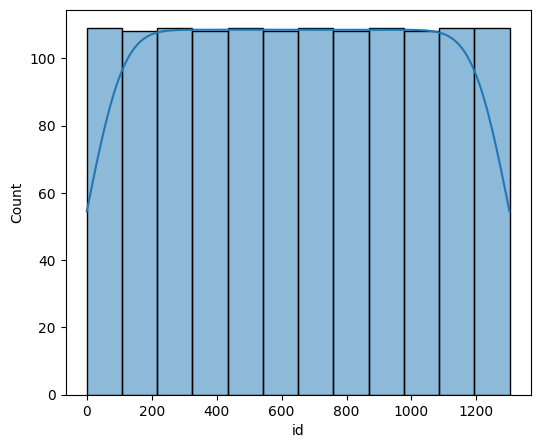

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


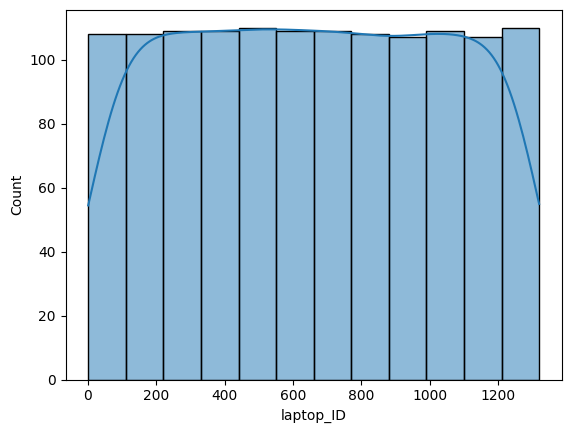

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


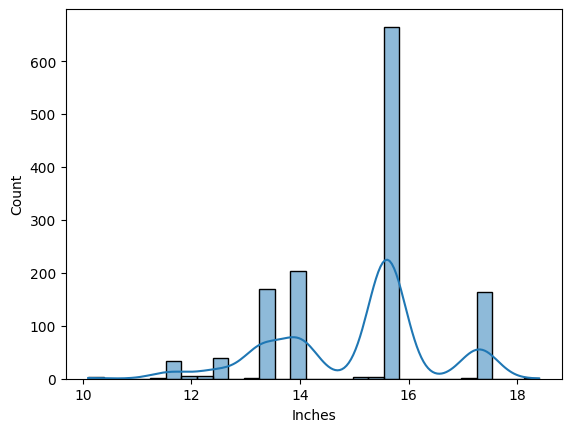

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


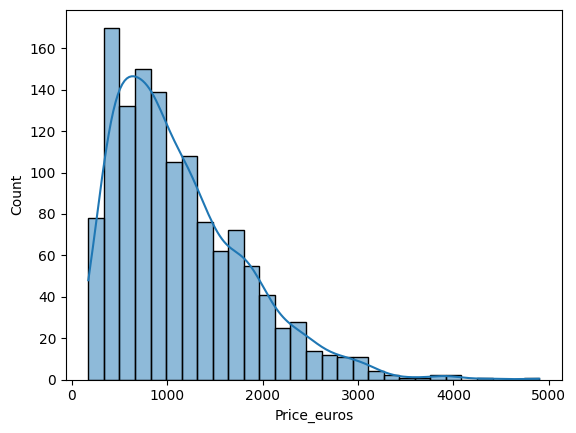

In [29]:
plt.figure(figsize=(6,5))
x=1
for i in num_cols:
    sns.histplot(data=combined,x=i,kde=True)
    print('\n')
    plt.show()

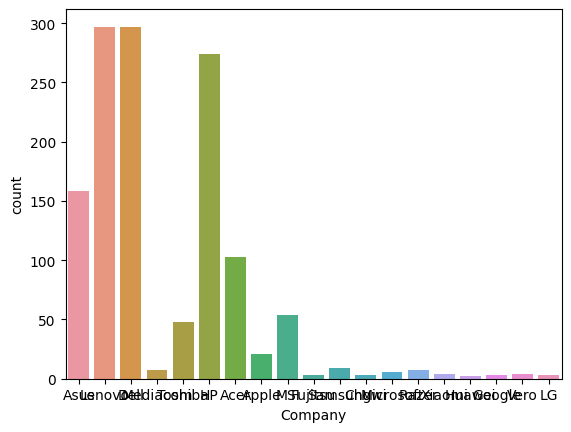

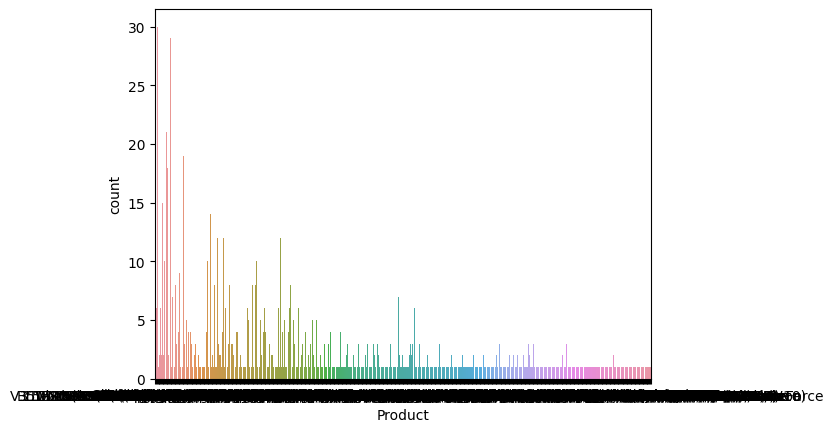

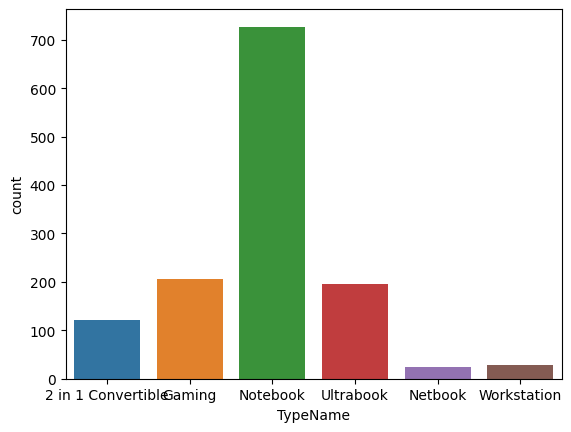

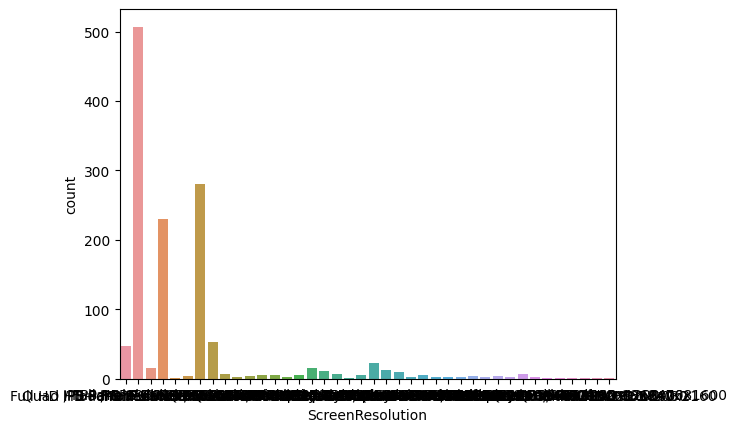

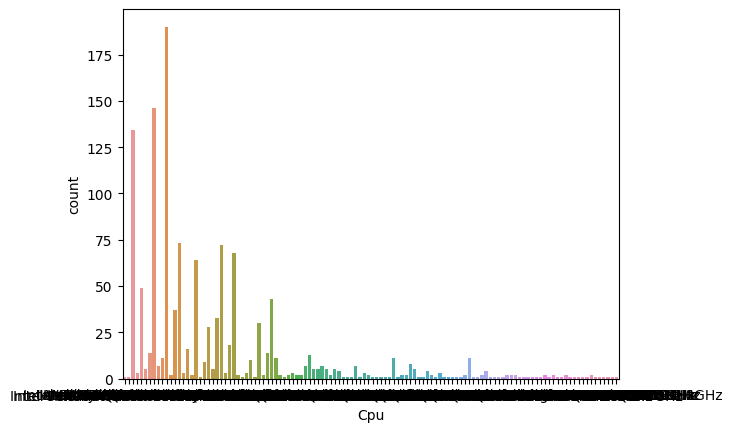

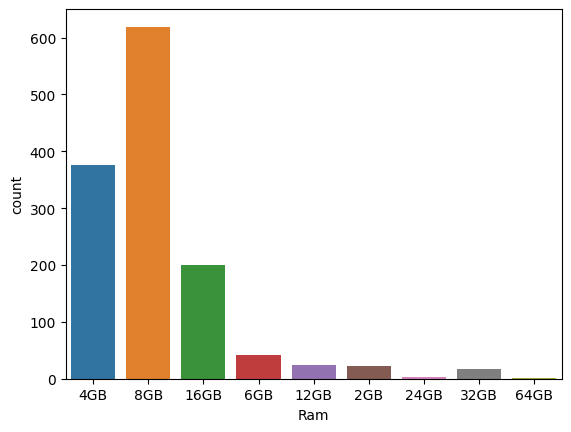

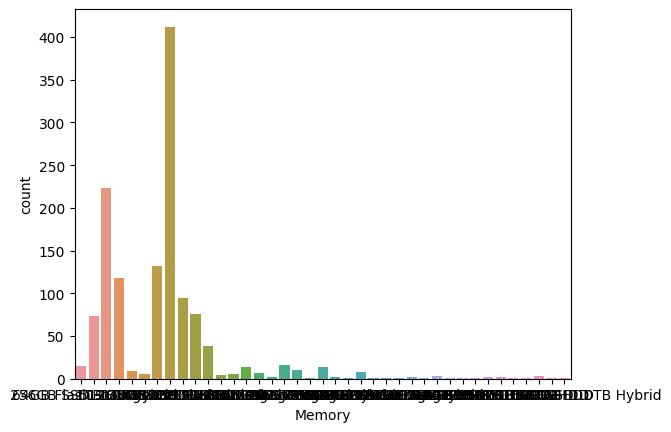

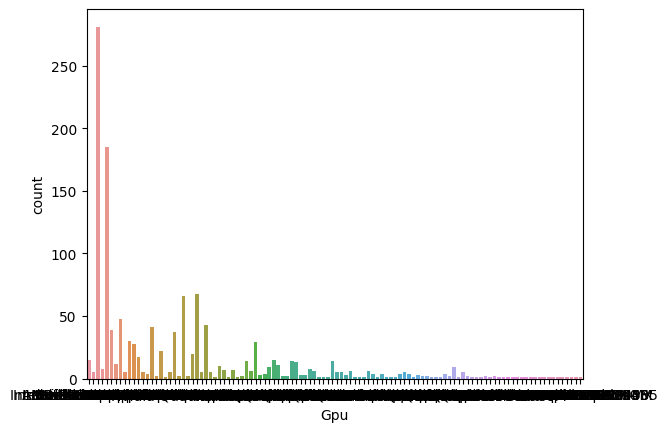

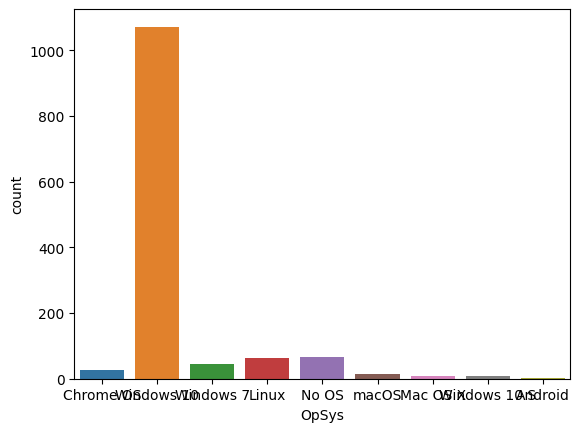

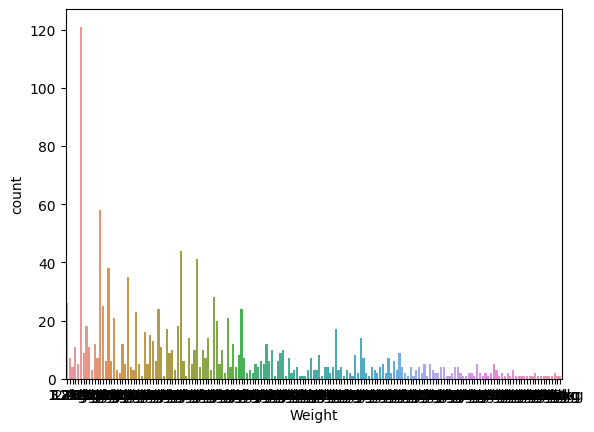

In [30]:
x=1
for i in cat_cols:
    sns.countplot(data=combined,x=i)
    print('\n')
    plt.show()

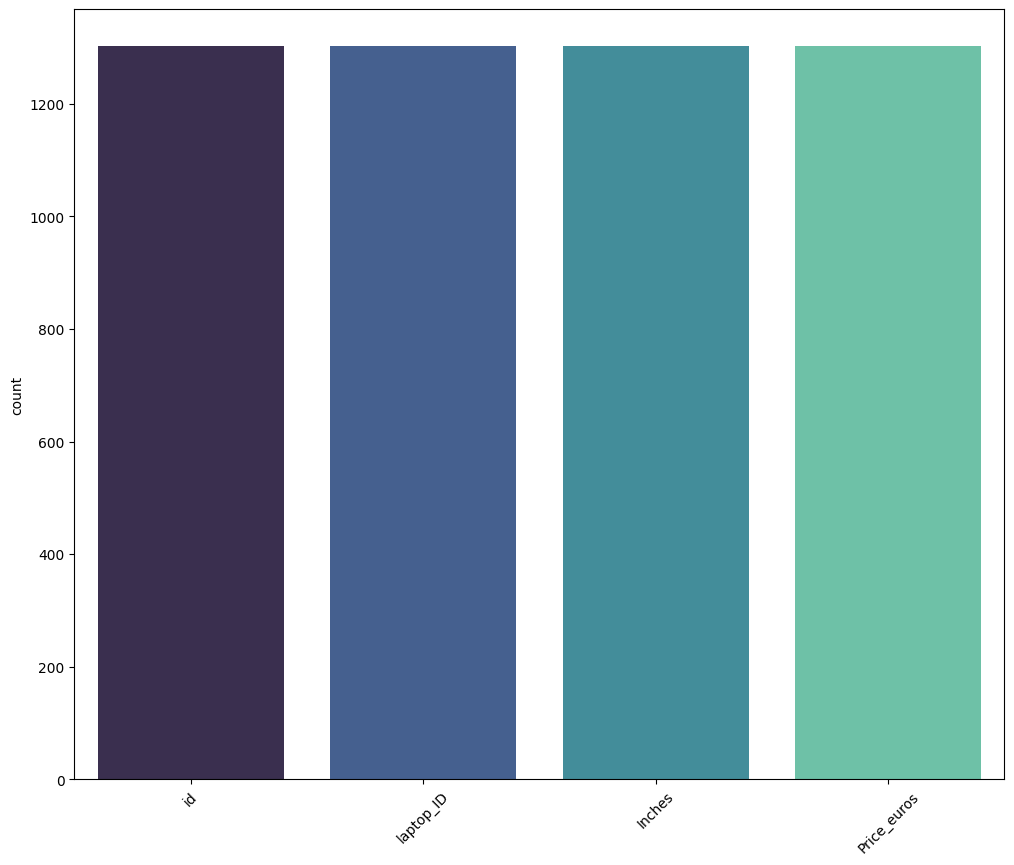

In [31]:
plt.figure(figsize=(12,10))
sns.countplot(combined,palette='mako');
plt.xticks(rotation=45);

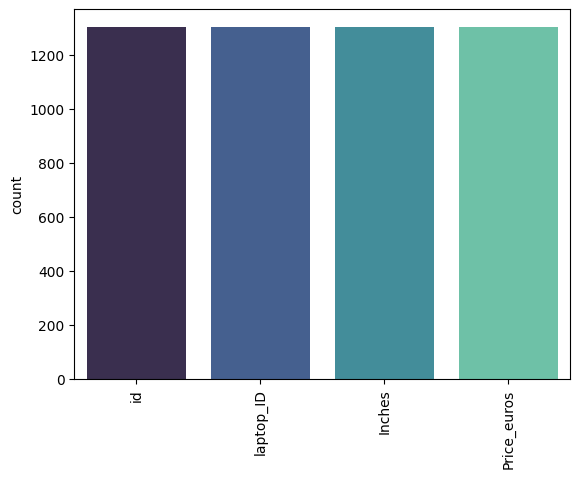

In [32]:
sns.countplot(combined,palette='mako');
plt.xticks(rotation=90);

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

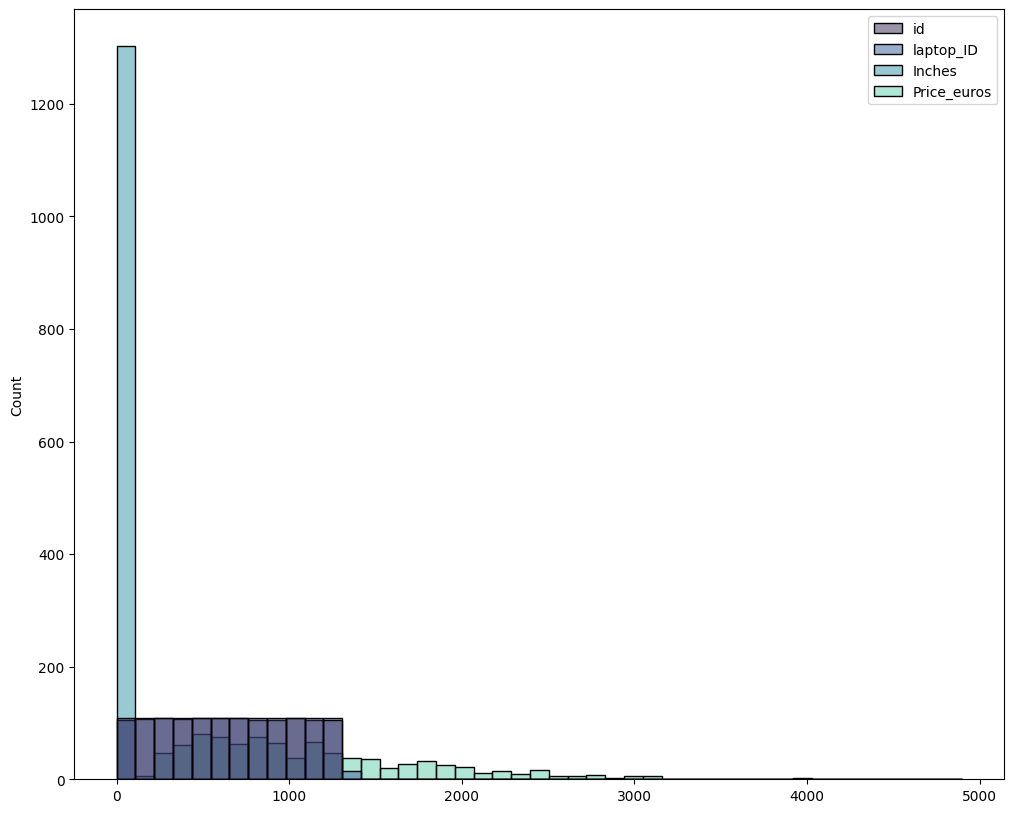

In [33]:
plt.figure(figsize=(12,10))
sns.histplot(combined,palette='mako');
plt.show()

In [34]:
combined['id']=combined['id'].map({'Good':2,'Standard':1,'Poor':0})

In [36]:
combined['id'].value_counts()

Series([], Name: count, dtype: int64)

In [37]:
combined['id'].unique()

array([nan])

In [38]:
combined['id'].isnull().sum()

1303

In [39]:
# Replacing weird values

In [40]:
combined = combined.applymap(lambda x:x if x is np.NaN or not isinstance(x,str)else str(x).strip('_,"')
                            ).replace(['','nan','!@9#%8','#F%$D@*&8'],np.NaN)

/tmp/ipykernel_31/1790175179.py:1: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  combined = combined.applymap(lambda x:x if x is np.NaN or not isinstance(x,str)else str(x).strip('_,"')


In [41]:
combined.head()

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,id,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
0,NaN,705,Asus,Chromebook Flip,2 in 1 Convertible,12.5,Full HD / Touchscreen 1920x1080,Intel Core M M3-6Y30 0.9GHz,4GB,64GB Flash Storage,Intel HD Graphics 515,Chrome OS,1.2kg,669.0
1,NaN,442,Asus,Rog Strix,Gaming,17.3,Full HD 1920x1080,AMD Ryzen 1600 3.2GHz,8GB,256GB SSD + 1TB HDD,AMD Radeon RX 580,Windows 10,3.2kg,1695.0
2,NaN,743,Lenovo,V310-15IKB (i7-7500U/4GB/1TB/FHD/W10),Notebook,15.6,Full HD 1920x1080,Intel Core i7 7500U 2.7GHz,4GB,1TB HDD,Intel HD Graphics 620,Windows 10,1.85kg,779.0
3,NaN,875,Dell,XPS 13,Ultrabook,13.3,Quad HD+ / Touchscreen 3200x1800,Intel Core i7 7660U 2.5GHz,16GB,512GB SSD,Intel Iris Plus Graphics 640,Windows 10,1.29kg,2240.0
4,NaN,1194,Lenovo,B51-80 (i7-6500U/4GB/1008GB/FHD/W7),Notebook,15.6,Full HD 1920x1080,Intel Core i7 6500U 2.5GHz,4GB,1.0TB Hybrid,Intel HD Graphics 520,Windows 7,2.32kg,825.0


In [42]:
# Treating type of laptop_ID
combined['id'].value_counts().head(9).index[1:]

Index([], dtype='float64', name='id')

In [43]:
# Rebuild type of laptop_ID columns
for i in combined['id'].value_counts().head(9).index[:1]:
    combined[i]=combined['id'].str.contains(i)

In [44]:
combined.head()

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,id,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
0,NaN,705,Asus,Chromebook Flip,2 in 1 Convertible,12.5,Full HD / Touchscreen 1920x1080,Intel Core M M3-6Y30 0.9GHz,4GB,64GB Flash Storage,Intel HD Graphics 515,Chrome OS,1.2kg,669.0
1,NaN,442,Asus,Rog Strix,Gaming,17.3,Full HD 1920x1080,AMD Ryzen 1600 3.2GHz,8GB,256GB SSD + 1TB HDD,AMD Radeon RX 580,Windows 10,3.2kg,1695.0
2,NaN,743,Lenovo,V310-15IKB (i7-7500U/4GB/1TB/FHD/W10),Notebook,15.6,Full HD 1920x1080,Intel Core i7 7500U 2.7GHz,4GB,1TB HDD,Intel HD Graphics 620,Windows 10,1.85kg,779.0
3,NaN,875,Dell,XPS 13,Ultrabook,13.3,Quad HD+ / Touchscreen 3200x1800,Intel Core i7 7660U 2.5GHz,16GB,512GB SSD,Intel Iris Plus Graphics 640,Windows 10,1.29kg,2240.0
4,NaN,1194,Lenovo,B51-80 (i7-6500U/4GB/1008GB/FHD/W7),Notebook,15.6,Full HD 1920x1080,Intel Core i7 6500U 2.5GHz,4GB,1.0TB Hybrid,Intel HD Graphics 520,Windows 7,2.32kg,825.0


In [45]:
combined.drop('id',inplace=True,axis=1)

In [46]:
mapping = combined.groupby('laptop_ID')['Inches'].mean().to_dict()

In [47]:
combined['Inches']=combined['laptop_ID'].map(mapping)

In [48]:
combined['Inches']=combined['Inches'].astype(int)

In [49]:
combined.head()

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
0,705,Asus,Chromebook Flip,2 in 1 Convertible,12,Full HD / Touchscreen 1920x1080,Intel Core M M3-6Y30 0.9GHz,4GB,64GB Flash Storage,Intel HD Graphics 515,Chrome OS,1.2kg,669.0
1,442,Asus,Rog Strix,Gaming,17,Full HD 1920x1080,AMD Ryzen 1600 3.2GHz,8GB,256GB SSD + 1TB HDD,AMD Radeon RX 580,Windows 10,3.2kg,1695.0
2,743,Lenovo,V310-15IKB (i7-7500U/4GB/1TB/FHD/W10),Notebook,15,Full HD 1920x1080,Intel Core i7 7500U 2.7GHz,4GB,1TB HDD,Intel HD Graphics 620,Windows 10,1.85kg,779.0
3,875,Dell,XPS 13,Ultrabook,13,Quad HD+ / Touchscreen 3200x1800,Intel Core i7 7660U 2.5GHz,16GB,512GB SSD,Intel Iris Plus Graphics 640,Windows 10,1.29kg,2240.0
4,1194,Lenovo,B51-80 (i7-6500U/4GB/1008GB/FHD/W7),Notebook,15,Full HD 1920x1080,Intel Core i7 6500U 2.5GHz,4GB,1.0TB Hybrid,Intel HD Graphics 520,Windows 7,2.32kg,825.0


In [50]:
combined.isnull().sum()

laptop_ID             0
Company               0
Product               0
TypeName              0
Inches                0
ScreenResolution      0
Cpu                   0
Ram                   0
Memory                0
Gpu                   0
OpSys                 0
Weight                0
Price_euros         391
dtype: int64

In [51]:
# Replacing nm vlaues in Ram
combined['Ram']=combined['Ram'].replace({'NM':'Other'})

In [52]:
combined['Ram'].value_counts()

Ram
8GB     619
4GB     375
16GB    200
6GB      41
12GB     25
2GB      22
32GB     17
24GB      3
64GB      1
Name: count, dtype: int64

In [53]:
combined.head()

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
0,705,Asus,Chromebook Flip,2 in 1 Convertible,12,Full HD / Touchscreen 1920x1080,Intel Core M M3-6Y30 0.9GHz,4GB,64GB Flash Storage,Intel HD Graphics 515,Chrome OS,1.2kg,669.0
1,442,Asus,Rog Strix,Gaming,17,Full HD 1920x1080,AMD Ryzen 1600 3.2GHz,8GB,256GB SSD + 1TB HDD,AMD Radeon RX 580,Windows 10,3.2kg,1695.0
2,743,Lenovo,V310-15IKB (i7-7500U/4GB/1TB/FHD/W10),Notebook,15,Full HD 1920x1080,Intel Core i7 7500U 2.7GHz,4GB,1TB HDD,Intel HD Graphics 620,Windows 10,1.85kg,779.0
3,875,Dell,XPS 13,Ultrabook,13,Quad HD+ / Touchscreen 3200x1800,Intel Core i7 7660U 2.5GHz,16GB,512GB SSD,Intel Iris Plus Graphics 640,Windows 10,1.29kg,2240.0
4,1194,Lenovo,B51-80 (i7-6500U/4GB/1008GB/FHD/W7),Notebook,15,Full HD 1920x1080,Intel Core i7 6500U 2.5GHz,4GB,1.0TB Hybrid,Intel HD Graphics 520,Windows 7,2.32kg,825.0


In [54]:
x = combined[['laptop_ID']]

In [55]:
y = combined[['laptop_ID']]

In [56]:
from sklearn.model_selection import train_test_split

In [57]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3)

In [58]:
from sklearn.linear_model import LinearRegression

In [59]:
lr = LinearRegression()

In [60]:
lr.fit(x_train,y_train)

LinearRegression()

In [61]:
y_pred=lr.predict(x_test)

In [62]:
y_test.head(),y_pred[0:5]

(     laptop_ID
 177        762
 232        244
 698       1006
 15         348
 259       1269,
 array([[ 762.],
        [ 244.],
        [1006.],
        [ 348.],
        [1269.]]))

In [63]:
from sklearn.metrics import mean_squared_error

In [64]:
mean_squared_error (y_test,y_pred)

1.0882312582223113e-25

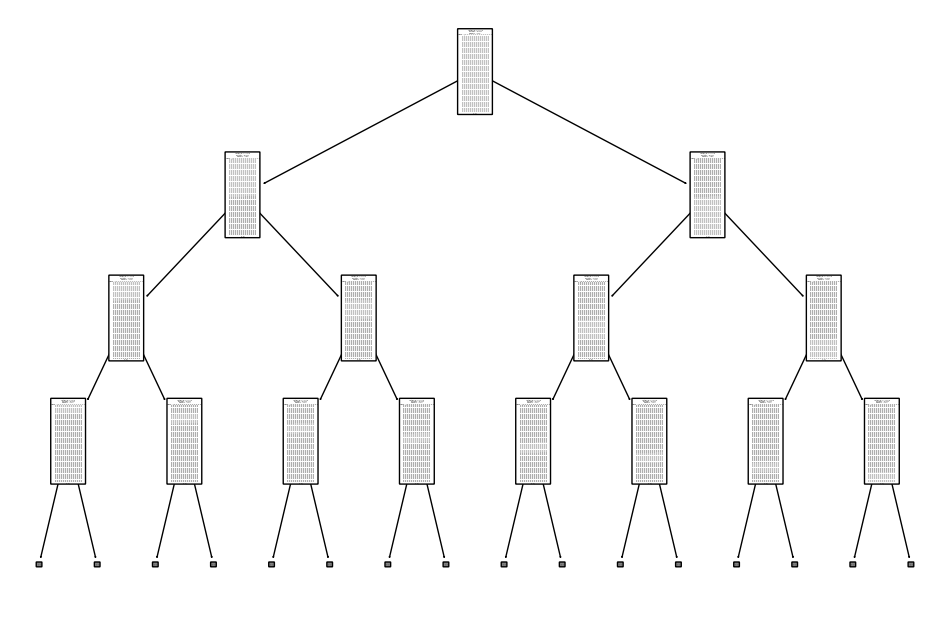

In [67]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

decision_tree_classification = DecisionTreeClassifier(criterion='entropy',random_state=10)
decision_tree = decision_tree_classification.fit(x_train,y_train)

plt.figure(figsize=(12,8))
plot_tree(decision_tree, max_depth=3, feature_names=x_train.columns, rounded=True)
plt.show()

In [68]:
y_pred_test = decision_tree.predict(x_test)
y_pred_train = decision_tree.predict(x_train)
print(decision_tree)


DecisionTreeClassifier(criterion='entropy', random_state=10)


In [69]:
from sklearn.metrics import classification_report

print(classification_report(y_train,y_pred_train))

              precision    recall  f1-score   support

           1       1.00      1.00      1.00         1
           2       1.00      1.00      1.00         1
           3       1.00      1.00      1.00         1
           4       1.00      1.00      1.00         1
           5       1.00      1.00      1.00         1
           7       1.00      1.00      1.00         1
           9       1.00      1.00      1.00         1
          10       1.00      1.00      1.00         1
          12       1.00      1.00      1.00         1
          13       1.00      1.00      1.00         1
          15       1.00      1.00      1.00         1
          16       1.00      1.00      1.00         1
          19       1.00      1.00      1.00         1
          20       1.00      1.00      1.00         1
          22       1.00      1.00      1.00         1
          27       1.00      1.00      1.00         1
          28       1.00      1.00      1.00         1
          29       1.00    

In [70]:
print(len(y_train), len(y_pred_train))

912 912


In [72]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100,random_state=42)
model.fit(x_train,y_train)

/tmp/ipykernel_31/1408708486.py:4: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  model.fit(x_train,y_train)


RandomForestClassifier(random_state=42)

In [73]:
y_pred = model.predict(x_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           5       0.00      0.00      0.00       0.0
           6       0.00      0.00      0.00       1.0
           7       0.00      0.00      0.00       0.0
           8       0.00      0.00      0.00       1.0
          10       0.00      0.00      0.00       0.0
          11       0.00      0.00      0.00       1.0
          13       0.00      0.00      0.00       0.0
          14       0.00      0.00      0.00       1.0
          16       0.00      0.00      0.00       0.0
          17       0.00      0.00      0.00       1.0
          18       0.00      0.00      0.00       1.0
          19       0.00      0.00      0.00       0.0
          20       0.00      0.00      0.00       0.0
          21       0.00      0.00      0.00       1.0
          22       0.00      0.00      0.00       0.0
          23       0.00      0.00      0.00       1.0
          24       0.00      0.00      0.00       1.0
          25       0.00    

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.